# House Price Prediction using Linear Regression

## Objective

To predict house prices based on area, number of bedrooms and number of bathrooms using a Linear Regression model.

## Technologies Used

- Python
- Pandas
- Matplotlib
- Scikit-learn
- Jupyter Notebook

## Dataset Used

Housing.csv

In [ ]:
# Import pandas and load the dataset
import pandas as pd

df = pd.read_csv("Housing.csv")

df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [ ]:
# Display all column names
df.columns


Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [ ]:
# Displays dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   price             545 non-null    int64
 1   area              545 non-null    int64
 2   bedrooms          545 non-null    int64
 3   bathrooms         545 non-null    int64
 4   stories           545 non-null    int64
 5   mainroad          545 non-null    str  
 6   guestroom         545 non-null    str  
 7   basement          545 non-null    str  
 8   hotwaterheating   545 non-null    str  
 9   airconditioning   545 non-null    str  
 10  parking           545 non-null    int64
 11  prefarea          545 non-null    str  
 12  furnishingstatus  545 non-null    str  
dtypes: int64(6), str(7)
memory usage: 55.5 KB


In [ ]:
# Checks for missing values in each column
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

In [ ]:
# Select input features and output variable
X=df[['area','bedrooms','bathrooms']]
y=df['price']
print(X.head())
print(y.head())

   area  bedrooms  bathrooms
0  7420         4          2
1  8960         4          4
2  9960         3          2
3  7500         4          2
4  7420         4          1
0    13300000
1    12250000
2    12250000
3    12215000
4    11410000
Name: price, dtype: int64


In [ ]:
# Split the dataset into training data (80%) and testing data (20%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(436, 3)
(109, 3)


In [ ]:
# Import and train the Linear Regression model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

print("Model trained successfully")

Model trained successfully


In [ ]:
# Predict house prices using the testing data
predictions = model.predict(X_test)

print(predictions[:5])

[6383168.05981192 6230250.35140428 3597885.28090091 4289730.8386382
 3930445.60575177]


In [ ]:
# Evaluate the model using MAE, MSE and R2 Score
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, predictions)

mse = mean_squared_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)

print("MSE:", mse)

print("R2 Score:", r2)

MAE: 1265275.6699454375
MSE: 2750040479309.052
R2 Score: 0.45592991188724463


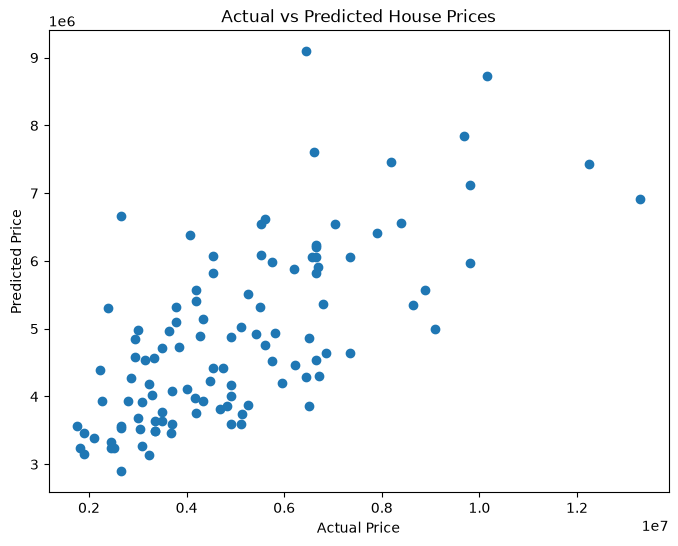

In [ ]:
# Plot a graph comparing actual and predicted house prices
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted House Prices")

plt.show()

In [ ]:
# Predict the price of a custom house entered by the user
new_house = pd.DataFrame(
    [[5000, 4, 3]],
    columns=['area', 'bedrooms', 'bathrooms']
)

predicted_price = model.predict(new_house)

print("Predicted Price:", predicted_price[0])

Predicted Price: 7494567.80437853
